<a href="https://colab.research.google.com/github/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/blob/main/Lecture-24-April-23-2026/Lecture-24_GNN_MeltingPoint-Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lecture 24 - GNN for Melting Point Prediction



In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install rdkit torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 83.5 MB/s eta 0:00:00


Import all basic pacakges

In [2]:
# basic
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# RDkit
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

# For progress bar
from tqdm.auto import tqdm

tqdm.pandas()

Download dataset

In [3]:
# Bash script to download all the dataset. Don't worry if you don't understand it
%%bash

url="https://raw.githubusercontent.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/refs/heads/main/Assignment-2/"
dataset_filename="BradleyDoublePlusGoodMeltingPointDataset.csv"

rm -f ${dataset_filename}

wget ${url}/${dataset_filename} &> /dev/null

ls

BradleyDoublePlusGoodMeltingPointDataset.csv
sample_data


Read dataset

In [4]:
data_mp = pd.read_csv("BradleyDoublePlusGoodMeltingPointDataset.csv")
data_mp = data_mp.drop(columns=['csid','link','source','count','min','max','range'])

In [5]:
data_mp

,key,name,smiles,mpC
0,27956,cyclobutylmethane,C1(CCC1)C,-161.51
1,16005,Nitrogen oxide,[O-][N+]#N,-90.80
2,16127,Sulfuryl difluoride,FS(F)(=O)=O,-135.80
3,17138,disopyramide,CC(C)N(CCC(c1ccccn1)(c2ccccc2)C(N)=O)C(C)C,94.80
4,15628,Bromine,BrBr,-7.20
...,...,...,...,...
3036,27698,4-Nitrobenzoic acid,C1=CC(=CC=C1C(=O)O)[N+](=O)[O-],240.00
3037,28584,Thalidomide,C1CC(=O)NC(=O)C1N2C(=O)C3=CC=CC=C3C2=O,275.00
3038,28068,Estradiol,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=C3...,176.00
3039,27580,"2,4,6-Trichlorophenol",C1=C(C=C(C(=C1Cl)O)Cl)Cl,65.00


In [6]:
def visualize_rdkit_mol_2d(mol):
  from rdkit.Chem.Draw import MolToImage
  from rdkit import Chem
  from rdkit.Chem import rdDepictor

  # Attempt to sanitize and kekulize the molecule for better depiction
  # It's good practice to make a copy if you don't want to modify the original supplier object's molecule
  sanitized_mol = Chem.Mol(mol) # Create a copy
  try:
      Chem.SanitizeMol(sanitized_mol)
      # Kekulize for clearer ring depictions, if applicable
      Chem.Kekulize(sanitized_mol)
  except Exception as e:
      print(f"Warning: Could not sanitize or kekulize molecule at index {mol_index}: {e}")
      sanitized_mol = mol # Fallback to original if sanitization fails

  # Compute 2D coordinates for the (potentially) sanitized molecule
  rdDepictor.Compute2DCoords(sanitized_mol)

  # Visualize the molecule
  img = MolToImage(sanitized_mol, size=(300, 300))
  display(img)

## RDKit mol (or SMILES) to PyG Graph

In [7]:
import torch
from torch_geometric.data import Data

ATOM_FEATURES = {
    "atomic_num":       list(range(1, 54)),
    "degree":           [1, 2, 3, 4],
    "formal_charge":    [-1, 0, 1],
    "chiral_tag":       [0, 1, 2],
    "hybridization":    [
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2,
    ],
}

BOND_FEATURES = {
    "bond_type": [
        Chem.rdchem.BondType.SINGLE,
        Chem.rdchem.BondType.DOUBLE,
        Chem.rdchem.BondType.TRIPLE,
        Chem.rdchem.BondType.AROMATIC,
    ],
    "stereo": [0, 1, 2, 3]
}


def one_hot(value, choices):
    """One-hot encode a value; unknown → all-zeros."""
    encoding = [0] * (len(choices) + 1)
    idx = choices.index(value) if value in choices else len(choices)
    encoding[idx] = 1
    return encoding


def atom_features(atom) -> list:
    feats = []
    feats += one_hot(atom.GetAtomicNum(),        ATOM_FEATURES["atomic_num"])
    feats += one_hot(atom.GetDegree(),           ATOM_FEATURES["degree"])
    feats += one_hot(atom.GetFormalCharge(),     ATOM_FEATURES["formal_charge"])
    feats += one_hot(int(atom.GetChiralTag()),   ATOM_FEATURES["chiral_tag"])
    feats += one_hot(atom.GetHybridization(),    ATOM_FEATURES["hybridization"])
    feats.append(int(atom.GetIsAromatic()))
    return feats


def bond_features(bond) -> list:
    feats = []
    feats += one_hot(bond.GetBondType(),         BOND_FEATURES["bond_type"])
    feats += one_hot(int(bond.GetStereo()),      BOND_FEATURES["stereo"])
    feats.append(int(bond.GetIsConjugated()))
    feats.append(int(bond.IsInRing()))
    return feats



def mol_to_graph(mol, y=None):

    if mol is None:
        return None

    # Atom features
    x = torch.tensor(
        [atom_features(a) for a in mol.GetAtoms()], dtype=torch.float
    )

    # Bond features (undirected => two directed edges per bond)
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr  += [bf, bf]

    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, len(bond_features(
            mol.GetBondWithIdx(0)
        ))), dtype=torch.float) if mol.GetNumBonds() > 0 else torch.zeros((0, 14), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    if y is not None:
        data.y = torch.tensor([y], dtype=torch.float)
    return data

def smi_to_graph(smi, y=None):
    mol = Chem.MolFromSmiles(smi)
    return mol_to_graph(mol, y)

## Visualize Graph

In [8]:
def visualize_graph(mol_graph):
  from torch_geometric.utils import to_networkx
  import networkx as nx
  import matplotlib.pyplot as plt
  import torch

  data_instance = mol_graph

  # Convert the PyG graph to a NetworkX graph
  G = to_networkx(data_instance, to_undirected=True)

  # Define mapping for atomic numbers to element symbols
  atomic_number_map = {
      1: 'H', 2: 'He', 3: 'Li', 4: 'Be', 5: 'B',
      6: 'C', 7: 'N', 8: 'O', 9: 'F', 14: 'Si', 15: 'P',
      16: 'S', 17: 'Cl', 35: 'Br', 53: 'I'
  }

  # Prepare node labels (atom types)
  node_labels = {}
  # The length of the one-hot vector for atomic_num is len(ATOM_FEATURES["atomic_num"]) + 1
  atomic_num_choices = ATOM_FEATURES["atomic_num"]
  one_hot_vec_len = len(atomic_num_choices) + 1

  for i, node_features_tensor in enumerate(data_instance.x):
      # Extract the one-hot encoded atomic number part
      atomic_num_one_hot_vector = node_features_tensor[:one_hot_vec_len]

      # Find the index of the '1' in the one-hot vector
      atomic_num_idx = torch.argmax(atomic_num_one_hot_vector).item()

      # Convert the index back to the actual atomic number
      if atomic_num_idx < len(atomic_num_choices):
          atomic_num = atomic_num_choices[atomic_num_idx]
      else:
          # This means the atomic number was not in the choices list (e.g., if one_hot encoded it as 'unknown')
          atomic_num = 0 # Represent as unknown or fallback

      node_labels[i] = atomic_number_map.get(atomic_num, f'Unknown({atomic_num})')

  # Define mapping for edge attributes (bond types)
  # Assuming edge_attr is a one-hot encoding for [single, double, triple, aromatic]
  bond_type_map = {
      0: 'single',
      1: 'double',
      2: 'triple',
      3: 'aromatic'
  }

  # Prepare edge labels
  edge_labels = {}
  # Iterate through the original PyG edge_index and edge_attr to get labels
  # edge_index.t() transposes (2, num_edges) to (num_edges, 2) for easier iteration
  for i, (u, v) in enumerate(data_instance.edge_index.t().tolist()):
      # Get the one-hot encoded attribute vector for the current edge
      attr_vector = data_instance.edge_attr[i]

      # Determine the bond type from the one-hot vector
      # Only process if the vector has a '1' (i.e., it's a valid one-hot)
      if attr_vector.sum() > 0:
          bond_type_idx = torch.argmax(attr_vector).item()
          label = bond_type_map.get(bond_type_idx, f"type_{bond_type_idx}")
      else:
          label = "unknown" # Fallback for unexpected attribute vectors

      # Add the label to the dictionary. NetworkX's draw_networkx_edge_labels
      # will correctly match this label to the undirected edge in G.
      # We'll add it for the (u, v) pair as it appears in edge_index.
      edge_labels[(u, v)] = label


  plt.figure(figsize=(6, 6)) # Make figure slightly larger to accommodate labels
  pos = nx.spring_layout(G, seed=42) # Use a fixed seed for reproducible layout

  # Draw nodes and edges
  nx.draw_networkx(G, pos,
                  labels=node_labels, # Use atom types as node labels
                  node_color='skyblue',
                  node_size=700, # Slightly larger nodes
                  font_size=10,
                  font_weight='bold',
                  width=1.5) # Slightly thicker edges

  # Draw edge labels
  nx.draw_networkx_edge_labels(G, pos,
                                edge_labels=edge_labels,
                                font_color='red',
                                font_size=8)

  plt.title(f"Graph Visualization")
  plt.axis('off') # Hide axes for cleaner look
  plt.show()

In [9]:
mol_graphs = []

for i, smi in enumerate(tqdm(data_mp['smiles'])):
    g = smi_to_graph(smi, y=data_mp.iloc[i]['mpC'])
    if g:
      mol_graphs.append(g)

  0%|          | 0/3041 [00:00<?, ?it/s]

[16:29:14] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[16:29:14] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6
[16:29:14] Can't kekulize mol.  Unkekulized atoms: 24 25 26 27 28 31 32 33 34
[16:29:14] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[16:29:14] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[16:29:14] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[16:29:14] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20 21 22 23 24
[16:29:15] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11
[16:29:15] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 8
[16:29:15] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[16:29:15] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[16:29:15] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[16:29:16] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 12 13 14 15 16
[16:29:16] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[16:29:16] Can't kekulize mol.  Unkekuliz

In [16]:
print(len(data_mp['smiles']))
print(len(mol_graphs))

3041
3025


In [11]:
print(mol_graphs[0].y)
print(data_mp['mpC'].iloc[0])

tensor([-161.5100])
-161.51


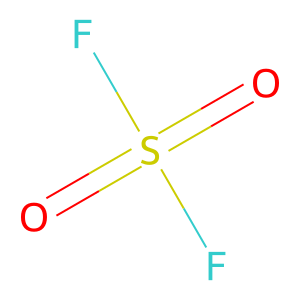

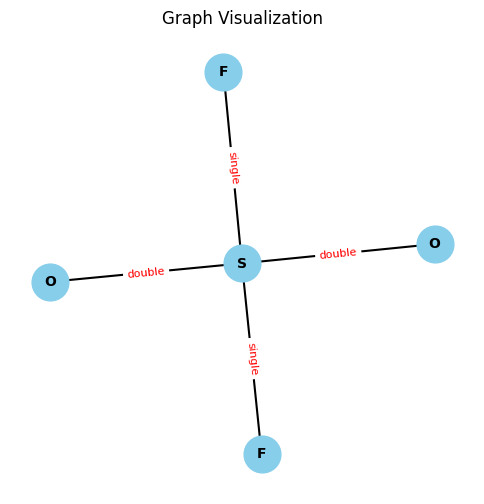

In [14]:
idx=2
visualize_rdkit_mol_2d(Chem.MolFromSmiles(data_mp['smiles'].iloc[idx]))
visualize_graph(mol_graphs[idx])

Setup datasets in data loader

In [17]:
print("Number of node features", mol_graphs[0].num_features)
print("Number of edge features", mol_graphs[0].num_edge_features)

Number of node features 74
Number of edge features 12


In [19]:
for i, g in enumerate(mol_graphs):
  if g.x.shape[1] != mol_graphs[0].num_features:
    print(f"Issue with node features of graph {i}: {g}")
    print(g.x.shape)

for i, g in enumerate(mol_graphs):
  if g.edge_attr.shape[1] != mol_graphs[0].num_edge_features:
    print(f"Issue with edge features of graph {i}: {g}")
    print(g.edge_attr.shape)



Issue with edge features of graph 813: Data(x=[1, 74], edge_index=[2, 0], edge_attr=[0, 14], y=[1])
torch.Size([0, 14])
Issue with edge features of graph 897: Data(x=[1, 74], edge_index=[2, 0], edge_attr=[0, 14], y=[1])
torch.Size([0, 14])


In [20]:
for i, g in enumerate(mol_graphs):
  if g.edge_attr.shape[1] != mol_graphs[0].num_edge_features:
    print(f"Issue with edge features of graph {i}: {g}")
    del mol_graphs[i]

Issue with edge features of graph 813: Data(x=[1, 74], edge_index=[2, 0], edge_attr=[0, 14], y=[1])
Issue with edge features of graph 896: Data(x=[1, 74], edge_index=[2, 0], edge_attr=[0, 14], y=[1])


In [21]:
print(len(data_mp['smiles']))
print(len(mol_graphs))

3041
3023


In [22]:
for i, g in enumerate(mol_graphs):
  if g.x.shape[1] != mol_graphs[0].num_features:
    print(f"Issue with node features of graph {i}: {g}")
    print(g.x.shape)

for i, g in enumerate(mol_graphs):
  if g.edge_attr.shape[1] != mol_graphs[0].num_edge_features:
    print(f"Issue with edge features of graph {i}: {g}")
    print(g.edge_attr.shape)

In [28]:
import random
mylist = [1, 2, 3, 4, 5]
print("Before:", mylist)
random.shuffle(mylist)
print("After:", mylist)


Before: [1, 2, 3, 4, 5]
After: [2, 1, 5, 3, 4]


In [72]:
from torch_geometric.loader import DataLoader
import random

random.shuffle(mol_graphs)

# data split
data_size = len(mol_graphs)
print("Size of full data set: ",data_size)
train_index = int(data_size * 0.8)
test_index = train_index + int(data_size * 0.1)
val_index = test_index + int(data_size * 0.1)

# datasets into DataLoader
train_loader = DataLoader(mol_graphs[0:train_index], batch_size=64, shuffle=True)
test_loader = DataLoader(mol_graphs[train_index:test_index], batch_size=64, shuffle=True)
val_loader = DataLoader(mol_graphs[test_index:val_index], batch_size=64, shuffle=True)

from torch_geometric.loader import PrefetchLoader
train_loader = PrefetchLoader(train_loader, device=device)
val_loader = PrefetchLoader(val_loader, device=device)
test_loader = PrefetchLoader(test_loader, device=device)

Size of full data set:  3023


In [73]:
print(len(train_loader))
# len(train_loader) gives the number of batches

38


In [34]:
import torch
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch_geometric.nn import GCNConv, GINConv
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, global_add_pool

In [35]:
class GCN(torch.nn.Module):
    """Graph Convolutional Network class with 3 convolutional layers and a linear layer"""

    def __init__(self, dim_input, dim_hidden):
        """init method for GCN

        Args:
            dim_hidden (int): the dimension of hidden layers
        """
        super().__init__()
        self.conv1 = GCNConv(dim_input, dim_hidden)
        self.conv2 = GCNConv(dim_hidden, dim_hidden)
        self.conv3 = GCNConv(dim_hidden, dim_hidden)
        self.lin = torch.nn.Linear(dim_hidden, 1)

    def forward(self, data):
        e = data.edge_index
        x = data.x

        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        x = x.relu()
        x = self.conv3(x, e)
        x = global_mean_pool(x, data.batch)

        x = Fun.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

In [87]:
class GIN(torch.nn.Module):
    """Graph Isomorphism Network class with 3 GINConv layers and 2 linear layers"""

    def __init__(self, dim_input, dim_hidden):
        """Initializing GIN class

        Args:
            dim_hidden (int): the dimension of hidden layers
        """
        super(GIN, self).__init__()
        self.conv1 = GINConv(
            Sequential(Linear(dim_input, dim_hidden), BatchNorm1d(dim_hidden), ReLU(), Linear(dim_hidden, dim_hidden), ReLU())
        )
        self.conv2 = GINConv(
            Sequential(
                Linear(dim_hidden, dim_hidden), BatchNorm1d(dim_hidden), ReLU(), Linear(dim_hidden, dim_hidden), ReLU()
            )
        )
        self.conv3 = GINConv(
            Sequential(
                Linear(dim_hidden, dim_hidden), BatchNorm1d(dim_hidden), ReLU(), Linear(dim_hidden, dim_hidden), ReLU()
            )
        )
        self.lin1 = Linear(dim_hidden, dim_hidden)
        self.lin2 = Linear(dim_hidden, 1)

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        batch = data.batch

        # Node embeddings
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = self.conv3(h, edge_index)

        # Graph-level readout
        h = global_add_pool(h, batch)

        h = self.lin1(h)
        h = h.relu()
        h = Fun.dropout(h, p=0.5, training=self.training)
        h = self.lin2(h)

        return h

In [84]:
def training(loader, model, loss, optimizer):
    """Training one epoch

    Args:
        loader (DataLoader): loader (DataLoader): training data divided into batches
        model (nn.Module): GNN model to train on
        loss (nn.functional): loss function to use during training
        optimizer (torch.optim): optimizer during training

    Returns:
        float: training loss
    """
    model.train()

    current_loss = 0
    for d in loader:
        optimizer.zero_grad()
        d.x = d.x.float()
        out = model(d)
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        current_loss += l / len(loader)
        l.backward()
        optimizer.step()
    return current_loss, model

@torch.no_grad()
def validation(loader, model, loss):
    """Validation

    Args:
        loader (DataLoader): validation set in batches
        model (nn.Module): current trained model
        loss (nn.functional): loss function

    Returns:
        float: validation loss
    """
    model.eval()
    val_loss = 0
    for d in loader:
        out = model(d)
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        val_loss += l / len(loader)
    return val_loss


@torch.no_grad()
def testing(loader, model):
    """Testing

    Args:
        loader (DataLoader): test dataset
        model (nn.Module): trained model

    Returns:
        float: test loss
    """
    loss = torch.nn.MSELoss()
    test_loss = 0
    test_target = numpy.empty((0))
    test_y_target = numpy.empty((0))
    for d in loader:
        out = model(d)
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        test_loss += l / len(loader)

        # save prediction vs ground truth values for plotting
        test_target = numpy.concatenate((test_target, out.detach().numpy()[:, 0]))
        test_y_target = numpy.concatenate((test_y_target, d.y.detach().numpy()))

    return test_loss, test_target, test_y_target


def train_epochs(epochs, learning_rate, model, train_loader, val_loader, file_path="best-model.pt"):
    import math
    """Training over all epochs

    Args:
        epochs (int): number of epochs to train for
        model (nn.Module): the current model
        train_loader (DataLoader): training data in batches
        val_loader (DataLoader): validation data in batches
        file_path (string): file to save the best model

    Returns:
        array: returning train and validation losses over all epochs
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss = torch.nn.MSELoss()

    train_loss = np.empty(epochs)
    val_loss = np.empty(epochs)
    best_loss = math.inf

    for epoch in range(epochs):
        epoch_loss, model = training(train_loader, model, loss, optimizer)
        v_loss = validation(val_loader, model, loss)
        if v_loss < best_loss:
            torch.save(model.state_dict(), f"{file_path}")
            best_loss = v_loss
        train_loss[epoch] = epoch_loss.detach().cpu().numpy()
        val_loss[epoch] = v_loss.detach().cpu().numpy()

        # print current train and val loss
        if epoch % 2 == 0:
            print(
                "Epoch: "
                + str(epoch)
                + ", Train loss: "
                + str(epoch_loss.item())
                + ", Val loss: "
                + str(v_loss.item())
            )
    return train_loss, val_loss

def plot_loss(loss_history, loss_val_history):
  plt.plot(loss_val_history, label='Total - Validation set')
  plt.plot(loss_history, label='Total - Training set')

  plt.yscale('log')
  plt.legend()
  plt.ylabel("Loss")
  plt.xlabel("Epoch")
  plt.show()


def plot_target(model, train_loader, val_loader, test_loader=None):

  model.eval()

  train_pred = np.empty((0))
  train_true = np.empty((0))
  val_pred = np.empty((0))
  val_true = np.empty((0))
  test_pred = np.empty((0))
  test_true = np.empty((0))

  with torch.no_grad():
      for d in train_loader:
          out = model(d)
          train_pred = np.concatenate((train_pred, out.detach().cpu().numpy()[:, 0]))
          train_true = np.concatenate((train_true, d.y.detach().cpu().numpy()))
      for d in val_loader:
          out = model(d)
          val_pred = np.concatenate((val_pred, out.detach().cpu().numpy()[:, 0]))
          val_true = np.concatenate((val_true, d.y.detach().cpu().numpy()))
      if test_loader:
        for d in test_loader:
            out = model(d)
            test_pred = np.concatenate((test_pred, out.detach().cpu().numpy()[:, 0]))
            test_true = np.concatenate((test_true, d.y.detach().cpu().numpy()))


  plt.plot(train_pred,train_true,'.',label='Train set')
  plt.plot(val_pred,val_true,'.',label='Validation set')
  if test_loader:
    plt.plot(test_pred,test_true,'.',label='Test set')
  # to get a diagonal line
  diagonal_line =np.linspace(np.min(train_true),np.max(train_true),1000)
  plt.plot(diagonal_line,diagonal_line, color='red', linestyle='--')
  # plt.axline([0, 0], slope=1, color='red', linestyle='--')
  plt.legend()
  plt.xlabel("Predicted Value")
  plt.ylabel("Actual Value")
  plt.show()

  plt.plot(train_pred,train_true-train_pred,'.',label='Train set')
  plt.plot(val_pred,val_true-val_pred,'.',label='Validation set')
  plt.plot(test_pred,test_true-test_pred,'.',label='Test set')
  plt.axhline(0, color='black', linewidth=1)
  plt.legend()
  plt.xlabel("Predicted Value")
  plt.ylabel("Residual (Actual-Predicted)")
  plt.show()

  sns.kdeplot(train_true-train_pred,label='Train set')
  sns.kdeplot(val_true-val_pred,label='Train set')
  sns.kdeplot(test_true-test_pred,label='Train set')
  plt.axvline(0, color='black', linewidth=1)
  plt.legend()
  plt.show()




In [39]:
dim_input = mol_graphs[0].num_features
print(dim_input)

74


In [40]:
print("Number of node features", mol_graphs[0].num_features)
print("Number of edge features", mol_graphs[0].num_edge_features)

Number of node features 74
Number of edge features 12


In [97]:
model_gcn = GCN(dim_input,dim_hidden=128)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ", device)
model_gcn.to(device)

print(model_gcn)
total_params = sum(p.numel() for p in model_gcn.parameters())
print(f"\nTotal parameters: {total_params:,}\n")


Device:  cuda
GCN(
  (conv1): GCNConv(74, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 128)
  (lin): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 42,753



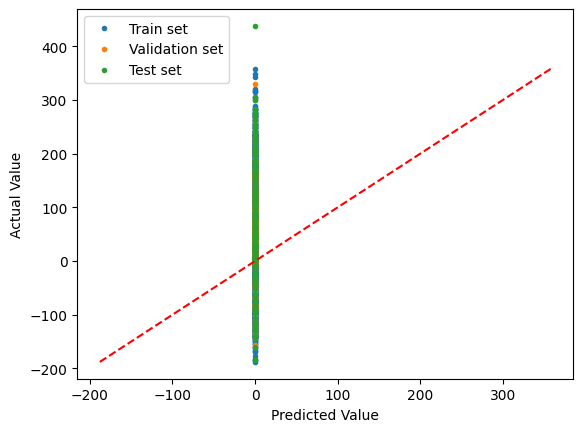

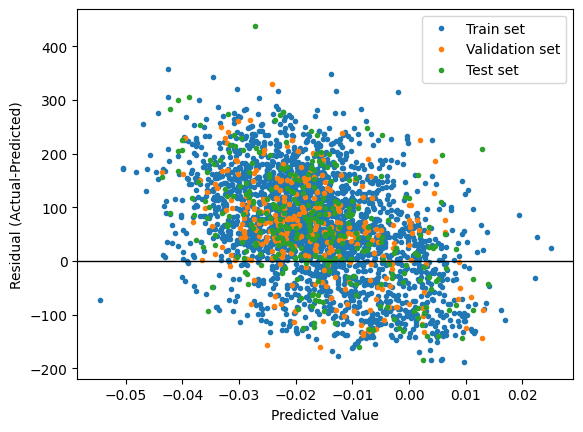

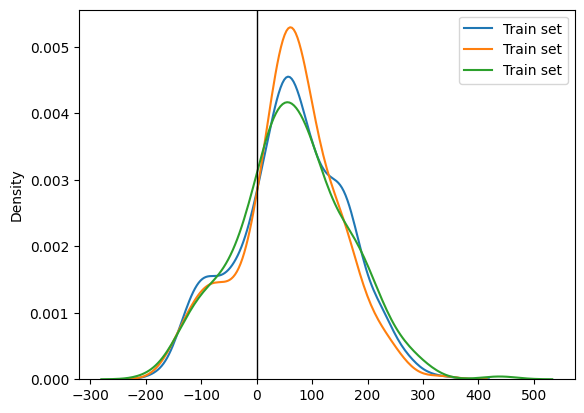

In [98]:
plot_target(model_gcn,train_loader,val_loader,test_loader)

In [99]:
epochs = 300
learning_rate = 1e-3

gcn_train_loss, gcn_val_loss = train_epochs(
    epochs=epochs,
    learning_rate=learning_rate,
    model=model_gcn,
    train_loader=train_loader,
    val_loader=val_loader,
    file_path="best-model-gcn.pt"
)

Epoch: 0, Train loss: 12103.26171875, Val loss: 7747.09423828125
Epoch: 2, Train loss: 6590.4111328125, Val loss: 5225.6865234375
Epoch: 4, Train loss: 5189.29833984375, Val loss: 4333.75341796875
Epoch: 6, Train loss: 4421.64306640625, Val loss: 3636.908447265625
Epoch: 8, Train loss: 3740.535400390625, Val loss: 3000.097412109375
Epoch: 10, Train loss: 3354.923828125, Val loss: 2764.162353515625
Epoch: 12, Train loss: 3132.858642578125, Val loss: 2504.44873046875
Epoch: 14, Train loss: 3039.67041015625, Val loss: 2449.123291015625
Epoch: 16, Train loss: 3057.903564453125, Val loss: 2420.054443359375
Epoch: 18, Train loss: 2908.226318359375, Val loss: 2390.329833984375
Epoch: 20, Train loss: 2926.1435546875, Val loss: 2323.9169921875
Epoch: 22, Train loss: 2878.0390625, Val loss: 2334.892333984375
Epoch: 24, Train loss: 2839.07275390625, Val loss: 2391.087158203125
Epoch: 26, Train loss: 2812.172607421875, Val loss: 2301.995361328125
Epoch: 28, Train loss: 2747.373046875, Val loss: 25

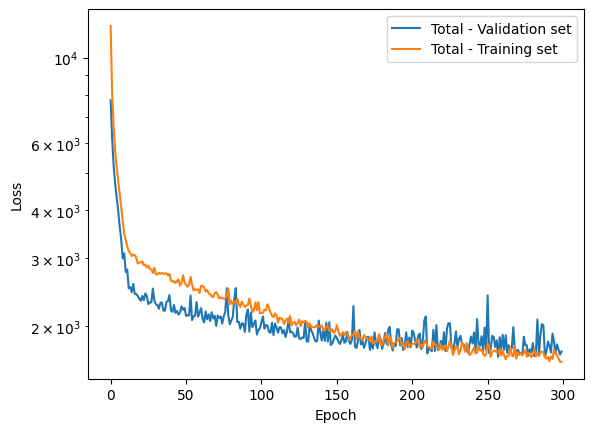

In [100]:
plot_loss(gcn_train_loss, gcn_val_loss)

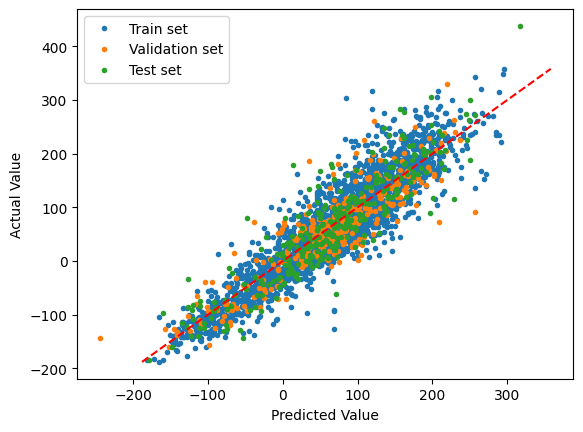

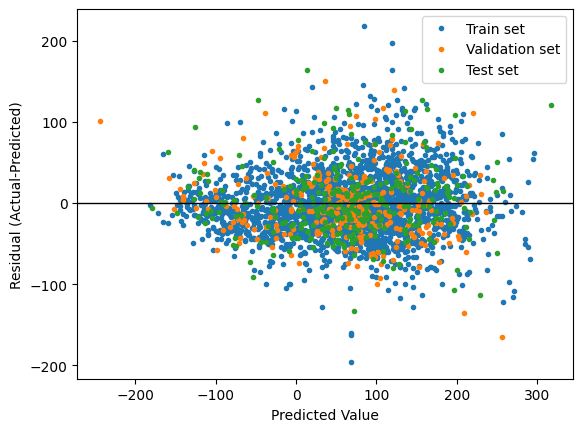

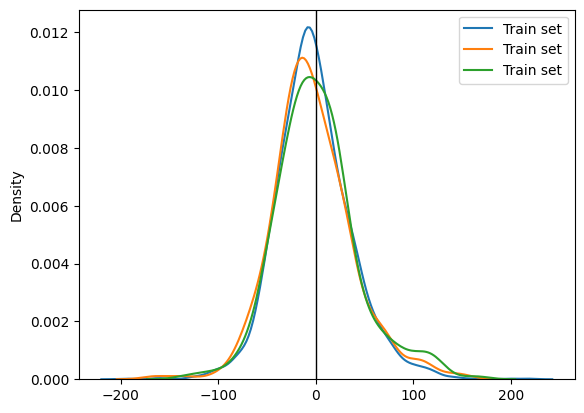

In [101]:
plot_target(model_gcn,train_loader,val_loader,test_loader)

In [85]:
!ls

best-model-gcn.pt.pt  BradleyDoublePlusGoodMeltingPointDataset.csv
best-model.pt.pt      sample_data


In [102]:
model_gin = GIN(dim_input,dim_hidden=128)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ", device)
model_gin.to(device)

print(model_gin)
total_params = sum(p.numel() for p in model_gcn.parameters())
print(f"\nTotal parameters: {total_params:,}\n")

Device:  cuda
GIN(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=74, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  ))
  (lin1): Linear(in_features=128, out_features=128, bias=True)
  (lin2): Linear(in_features=128, out_features=1, bias=True)
)



In [103]:
epochs = 300
learning_rate = 1e-3

gin_train_loss, gin_val_loss = train_epochs(
    epochs=epochs,
    learning_rate=learning_rate,
    model=model_gin,
    train_loader=train_loader,
    val_loader=val_loader,
    file_path="best-model-gin.pt"
)



Epoch: 0, Train loss: 7712.92138671875, Val loss: 5765.478515625
Epoch: 2, Train loss: 3868.96435546875, Val loss: 2735.741455078125
Epoch: 4, Train loss: 2683.556640625, Val loss: 2068.15771484375
Epoch: 6, Train loss: 2498.335693359375, Val loss: 2005.5489501953125
Epoch: 8, Train loss: 2360.745849609375, Val loss: 2023.333740234375
Epoch: 10, Train loss: 2258.16552734375, Val loss: 1980.900390625
Epoch: 12, Train loss: 2172.17431640625, Val loss: 1760.5880126953125
Epoch: 14, Train loss: 2062.9990234375, Val loss: 1703.8243408203125
Epoch: 16, Train loss: 2003.394287109375, Val loss: 1687.5057373046875
Epoch: 18, Train loss: 1913.904541015625, Val loss: 1688.5963134765625
Epoch: 20, Train loss: 1897.8634033203125, Val loss: 1562.014404296875
Epoch: 22, Train loss: 1865.6312255859375, Val loss: 2104.3564453125
Epoch: 24, Train loss: 1740.46826171875, Val loss: 1947.1707763671875
Epoch: 26, Train loss: 1729.8839111328125, Val loss: 1854.3167724609375
Epoch: 28, Train loss: 1896.436889

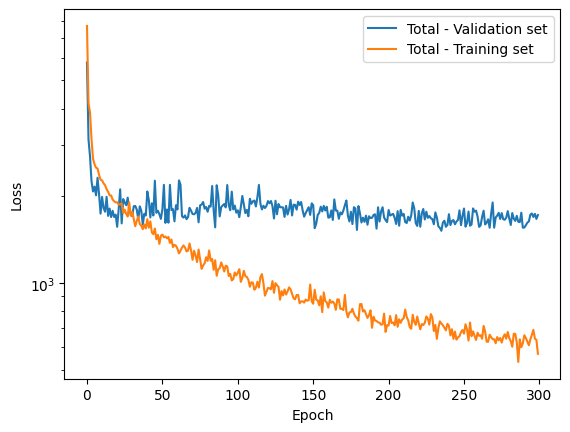

In [104]:
plot_loss(gin_train_loss, gin_val_loss)

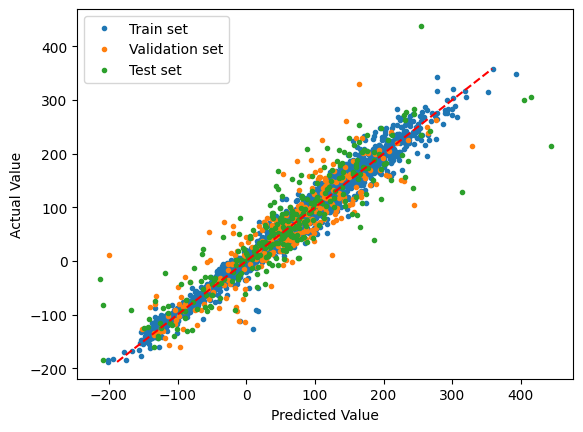

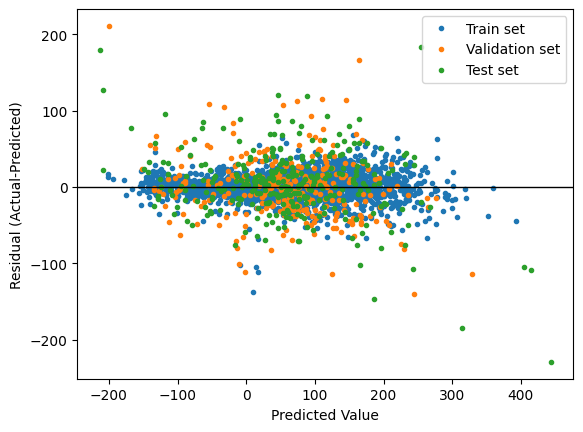

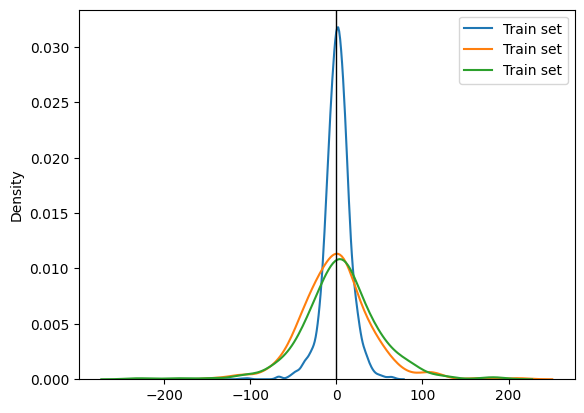

In [105]:
plot_target(model_gin,train_loader,val_loader,test_loader)

In [106]:
model_gin = GIN(dim_input,dim_hidden=64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ", device)
model_gin.to(device)

print(model_gin)
total_params = sum(p.numel() for p in model_gcn.parameters())
print(f"\nTotal parameters: {total_params:,}\n")

Device:  cuda
GIN(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=74, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (lin1): Linear(in_features=64, out_features=64, bias=True)
  (lin2): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters:

In [107]:
epochs = 300
learning_rate = 1e-3

gin_train_loss, gin_val_loss = train_epochs(
    epochs=epochs,
    learning_rate=learning_rate,
    model=model_gin,
    train_loader=train_loader,
    val_loader=val_loader,
    file_path="best-model-gin.pt"
)



Epoch: 0, Train loss: 9713.3759765625, Val loss: 4283.8369140625
Epoch: 2, Train loss: 3997.523681640625, Val loss: 2894.9833984375
Epoch: 4, Train loss: 3447.90234375, Val loss: 2972.529296875
Epoch: 6, Train loss: 2699.010986328125, Val loss: 1977.822998046875
Epoch: 8, Train loss: 2465.695068359375, Val loss: 2111.923828125
Epoch: 10, Train loss: 2445.50830078125, Val loss: 1877.039306640625
Epoch: 12, Train loss: 2379.115966796875, Val loss: 1986.445068359375
Epoch: 14, Train loss: 2261.947998046875, Val loss: 1756.53125
Epoch: 16, Train loss: 2165.401123046875, Val loss: 1684.320068359375
Epoch: 18, Train loss: 2067.857666015625, Val loss: 1686.3072509765625
Epoch: 20, Train loss: 2091.504150390625, Val loss: 2101.886474609375
Epoch: 22, Train loss: 2009.6431884765625, Val loss: 1721.0618896484375
Epoch: 24, Train loss: 1970.8489990234375, Val loss: 1766.910888671875
Epoch: 26, Train loss: 1933.8701171875, Val loss: 1739.435302734375
Epoch: 28, Train loss: 1939.3275146484375, Val 

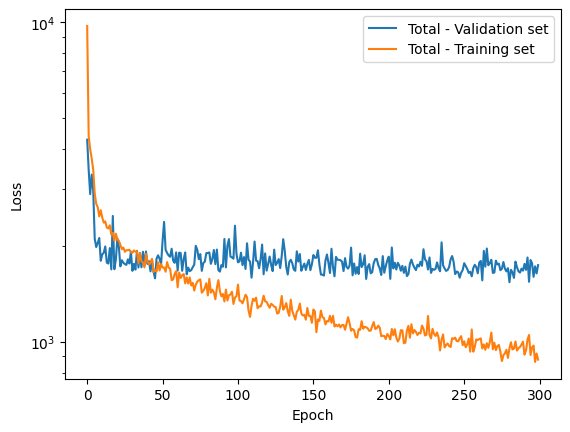

In [108]:
plot_loss(gin_train_loss, gin_val_loss)

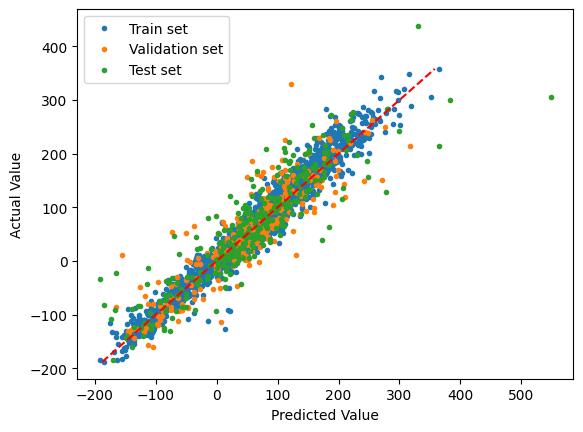

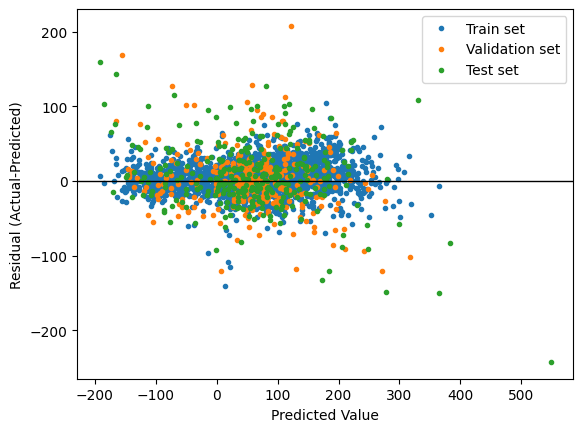

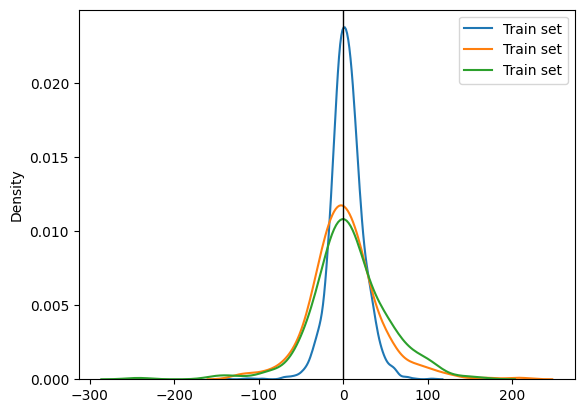

In [109]:
plot_target(model_gin,train_loader,val_loader,test_loader)